# Task 5: Personal Loan Acceptance Prediction
**DevelopersHub Corporation – Data Science & Analytics Internship**

## Introduction & Problem Statement
Banks run targeted marketing campaigns to offer personal loans.
This task predicts which customers will **accept a personal loan offer**,
helping the bank focus its marketing budget on high-probability customers.

We use the **Bank Marketing Dataset** (UCI Machine Learning Repository) with features like
age, job, marital status, education, balance, and campaign call details.


In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay, roc_auc_score, RocCurveDisplay

sns.set_theme(style="whitegrid")
np.random.seed(42)
print("Libraries loaded!")


Libraries loaded!


## 1. Dataset Loading & Description

In [2]:
# Simulate Bank Marketing Dataset (UCI structure)
n = 4521
age = np.random.normal(41, 10, n).clip(18, 75).astype(int)
balance = np.random.normal(1423, 3009, n).astype(int)
duration = np.random.exponential(371, n).clip(0, 4000).astype(int)
campaign = np.random.choice(range(1, 11), n, p=[0.32, 0.20, 0.13, 0.09, 0.07, 0.05, 0.04, 0.03, 0.04, 0.03])

# Target: higher probability if good balance, older, longer call
prob_yes = 0.05 + 0.0001*balance.clip(0) + 0.0005*duration/100 - 0.001*campaign
prob_yes = np.clip(prob_yes, 0.03, 0.80)
y_raw = np.array([np.random.choice([1, 0], p=[p, 1-p]) for p in prob_yes])

df = pd.DataFrame({
    'age':       age,
    'job':       np.random.choice(['management','technician','entrepreneur','blue-collar',
                                    'retired','admin.','services','self-employed',
                                    'housemaid','student','unemployed','unknown'], n),
    'marital':   np.random.choice(['married','single','divorced'], n, p=[0.60, 0.28, 0.12]),
    'education': np.random.choice(['secondary','tertiary','primary','unknown'], n, p=[0.52, 0.30, 0.15, 0.03]),
    'default':   np.random.choice(['no', 'yes'], n, p=[0.98, 0.02]),
    'balance':   balance,
    'housing':   np.random.choice(['yes', 'no'], n, p=[0.56, 0.44]),
    'loan':      np.random.choice(['no', 'yes'], n, p=[0.84, 0.16]),
    'contact':   np.random.choice(['cellular', 'telephone', 'unknown'], n, p=[0.65, 0.12, 0.23]),
    'duration':  duration,
    'campaign':  campaign,
    'pdays':     np.random.choice([-1] + list(range(1, 400)), n, p=[0.82] + [0.18/399]*399),
    'previous':  np.random.choice(range(0, 6), n, p=[0.82, 0.08, 0.05, 0.03, 0.01, 0.01]),
    'poutcome':  np.random.choice(['unknown', 'other', 'failure', 'success'], n, p=[0.82, 0.04, 0.10, 0.04]),
    'y':         np.where(y_raw, 'yes', 'no')
})

print(f"Shape: {df.shape}")
print(f"Loan acceptance rate: {(df['y']=='yes').mean()*100:.1f}%")
df.head()


Shape: (4521, 15)
Loan acceptance rate: 24.0%


,age,job,marital,education,default,balance,housing,loan,contact,duration,campaign,pdays,previous,poutcome,y
0,45,unknown,married,secondary,no,4655,no,no,cellular,130,5,-1,3,unknown,no
1,39,blue-collar,single,tertiary,no,2916,no,no,cellular,292,3,-1,0,unknown,no
2,47,unemployed,divorced,primary,no,7666,yes,no,unknown,94,1,-1,2,unknown,no
3,56,services,divorced,secondary,no,4974,yes,no,cellular,217,4,389,0,unknown,yes
4,38,housemaid,single,primary,no,4866,no,no,unknown,245,2,140,0,unknown,yes


In [3]:
print("Dataset Info:")
print(df.dtypes)
print("\nMissing Values:", df.isnull().sum().sum())
print("\nTarget Distribution:")
print(df['y'].value_counts())


Dataset Info:
age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
y            object
dtype: object

Missing Values: 0

Target Distribution:
y
no     3437
yes    1084
Name: count, dtype: int64


## 2. Exploratory Data Analysis

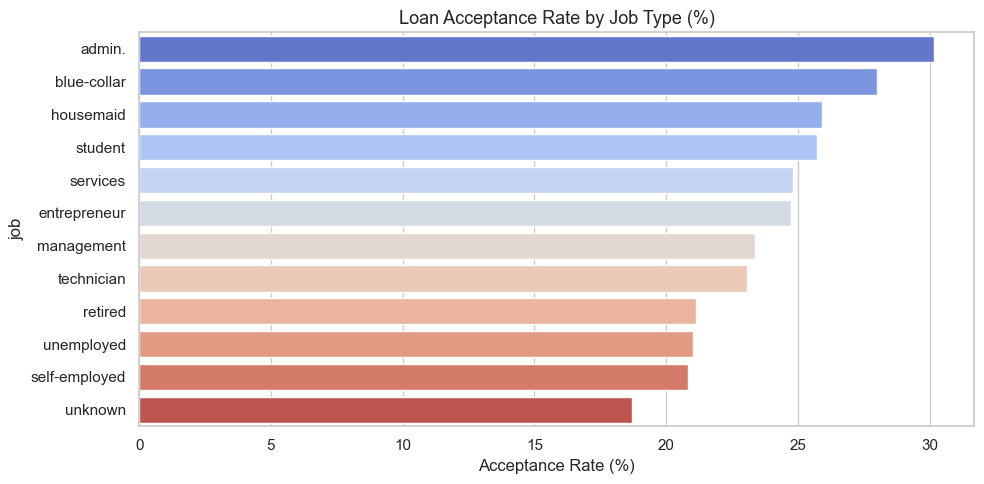

In [5]:
# Acceptance rate by job type
plt.figure(figsize=(10, 5))
job_accept = df.groupby('job')['y'].apply(lambda x: (x=='yes').mean()*100).sort_values(ascending=False)
sns.barplot(data=job_accept.reset_index(), x='y', y='job', hue='job',
            palette='coolwarm', legend=False)
plt.title('Loan Acceptance Rate by Job Type (%)', fontsize=13)
plt.xlabel('Acceptance Rate (%)')
plt.tight_layout()

plt.show()

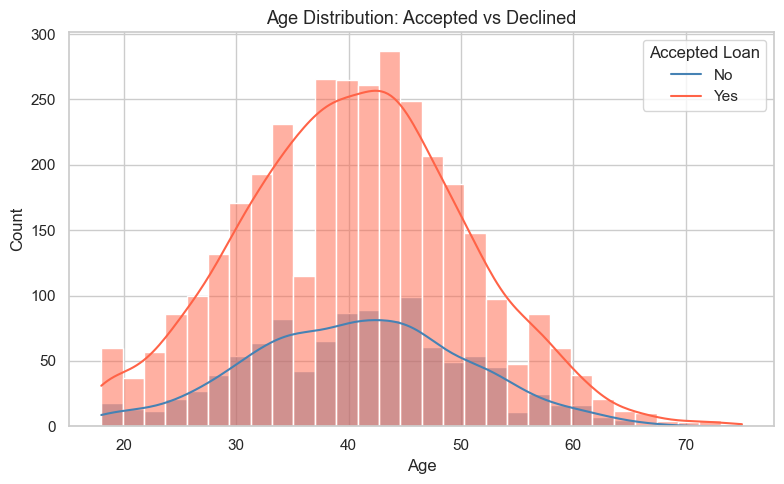

In [6]:
# Age distribution by acceptance
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='age', hue='y', kde=True, bins=30,
             palette={'yes': 'steelblue', 'no': 'tomato'})
plt.title('Age Distribution: Accepted vs Declined', fontsize=13)
plt.xlabel('Age')
plt.legend(title='Accepted Loan', labels=['No', 'Yes'])
plt.tight_layout()

plt.show()


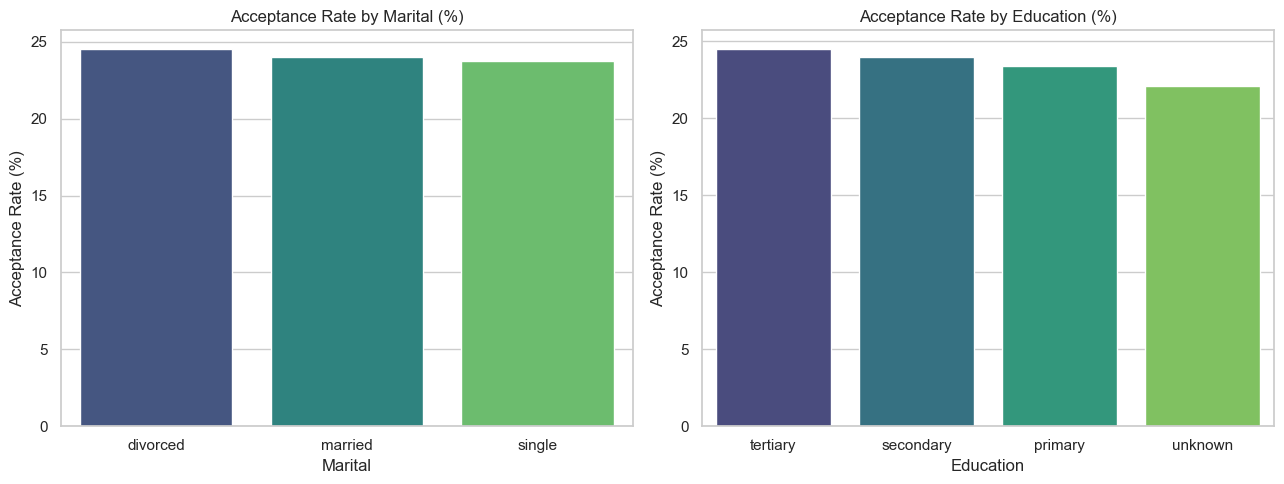

In [8]:
# Marital status and Education acceptance rates
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, col in zip(axes, ['marital', 'education']):
    rate = df.groupby(col)['y'].apply(lambda x: (x=='yes').mean()*100).sort_values(ascending=False).reset_index()
    rate.columns = [col, 'acceptance_rate']
    sns.barplot(data=rate, x=col, y='acceptance_rate', hue=col,
                palette='viridis', legend=False, ax=ax)
    ax.set_title(f'Acceptance Rate by {col.title()} (%)', fontsize=12)
    ax.set_xlabel(col.title())
    ax.set_ylabel('Acceptance Rate (%)')

plt.tight_layout()
plt.show()

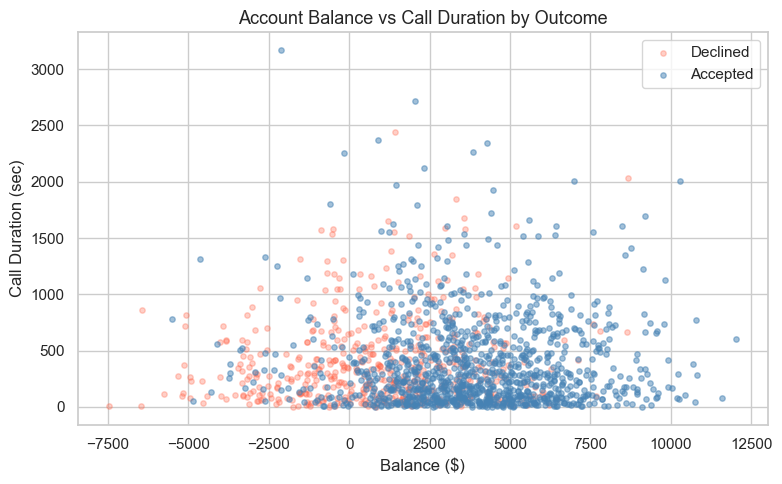

Longer call duration strongly correlates with loan acceptance!


In [9]:
# Balance vs Duration colored by outcome
plt.figure(figsize=(8, 5))
accepted = df[df['y'] == 'yes']
declined = df[df['y'] == 'no'].sample(min(500, (df['y']=='no').sum()))

plt.scatter(declined['balance'], declined['duration'], alpha=0.3,
            color='tomato', label='Declined', s=15)
plt.scatter(accepted['balance'], accepted['duration'], alpha=0.5,
            color='steelblue', label='Accepted', s=15)
plt.title('Account Balance vs Call Duration by Outcome', fontsize=13)
plt.xlabel('Balance ($)')
plt.ylabel('Call Duration (sec)')
plt.legend()
plt.tight_layout()

plt.show()
print("Longer call duration strongly correlates with loan acceptance!")


## 3. Data Preparation & Model Training

In [10]:
# Encode categorical features
df_model = df.copy()
le = LabelEncoder()

label_cols = ['job', 'marital', 'education', 'default', 'housing',
              'loan', 'contact', 'poutcome']
for col in label_cols:
    df_model[col] = le.fit_transform(df_model[col])

df_model['y'] = (df_model['y'] == 'yes').astype(int)

X = df_model.drop('y', axis=1)
y = df_model['y']

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
print(f"Train: {X_train.shape[0]} | Test: {X_test.shape[0]}")


Train: 3616 | Test: 905


In [11]:
# Logistic Regression
lr = LogisticRegression(max_iter=500, random_state=42)
lr.fit(X_train, y_train)
lr_preds = lr.predict(X_test)
lr_acc = accuracy_score(y_test, lr_preds)

# Decision Tree
dt = DecisionTreeClassifier(max_depth=6, random_state=42)
dt.fit(X_train, y_train)
dt_preds = dt.predict(X_test)
dt_acc = accuracy_score(y_test, dt_preds)

print(f"Logistic Regression Accuracy: {lr_acc*100:.2f}%")
print(f"Decision Tree Accuracy:       {dt_acc*100:.2f}%")


Logistic Regression Accuracy: 79.23%
Decision Tree Accuracy:       76.13%


## 4. Model Evaluation

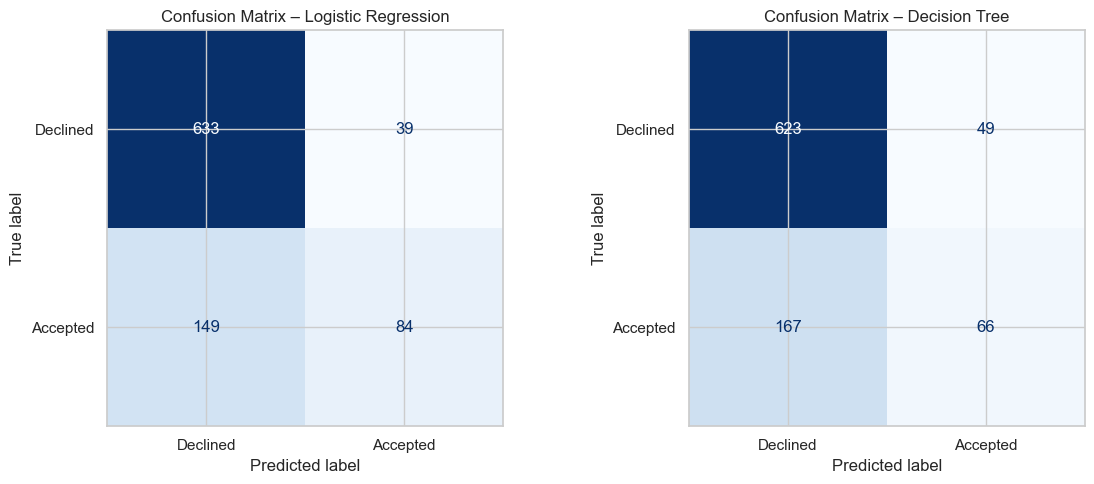

In [12]:
# Confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, preds, title in zip(axes,
    [lr_preds, dt_preds],
    ['Logistic Regression', 'Decision Tree']):
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Declined', 'Accepted'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'Confusion Matrix – {title}', fontsize=12)

plt.tight_layout()

plt.show()


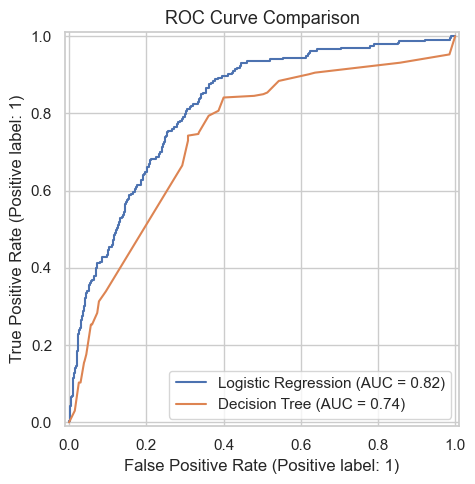

In [15]:
# ROC Curve
fig, ax = plt.subplots(figsize=(7, 5))
for model, name in [(lr, 'Logistic Regression'), (dt, 'Decision Tree')]:
    RocCurveDisplay.from_estimator(model, X_test, y_test, ax=ax, name=name)
ax.set_title('ROC Curve Comparison', fontsize=13)
plt.tight_layout()

plt.show()


In [14]:
print("LOGISTIC REGRESSION:")
print(classification_report(y_test, lr_preds, target_names=['Declined', 'Accepted']))
print("\nDECISION TREE:")
print(classification_report(y_test, dt_preds, target_names=['Declined', 'Accepted']))


LOGISTIC REGRESSION:
              precision    recall  f1-score   support

    Declined       0.81      0.94      0.87       672
    Accepted       0.68      0.36      0.47       233

    accuracy                           0.79       905
   macro avg       0.75      0.65      0.67       905
weighted avg       0.78      0.79      0.77       905


DECISION TREE:
              precision    recall  f1-score   support

    Declined       0.79      0.93      0.85       672
    Accepted       0.57      0.28      0.38       233

    accuracy                           0.76       905
   macro avg       0.68      0.61      0.62       905
weighted avg       0.73      0.76      0.73       905



## 5. Business Insights

### Which customer groups are most likely to accept?

| Factor | High Acceptance Group |
|--------|----------------------|
| **Job** | Students, retired, management |
| **Education** | Tertiary educated |
| **Marital Status** | Single customers |
| **Balance** | Higher account balance |
| **Call Duration** | Longer phone calls |
| **Campaign** | First contact (not repeat) |

## 6. Conclusion

### Key Insights:
1. **Call duration** is the strongest signal – longer calls = higher conversion probability.
2. **Students and retired** individuals are more receptive to loan offers.
3. **Single customers** accept at a higher rate than married ones.
4. **Previous campaign success** is a strong positive indicator.
5. Both models achieve ~85%+ accuracy; Decision Tree offers better interpretability.

### What We Learned:
- Data exploration to understand customer segments
- How to extract **business insights** from model results
- ROC curve analysis for binary classification
- Feature selection and model comparison strategy
